In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Устройство: {device}")

Устройство: cpu


In [9]:
BATCH_SIZE = 32
EPOCHS = 5
LEARNING_RATE = 0.001
DATA_DIR = "../data"

# Преобразования для обучения (с аугментацией)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Преобразования для теста (без аугментации)
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Загрузка датасета
full_dataset = datasets.ImageFolder(root=DATA_DIR, transform=train_transform)
print(f"Классы: {full_dataset.classes}")
print(f"Соответствие: {full_dataset.class_to_idx}")
print(f"Всего изображений: {len(full_dataset)}")

# Разделение: 80% обучение, 20% тест
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

print(f"Обучающая выборка: {train_size}")
print(f"Тестовая выборка: {test_size}")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Классы: ['Negative', 'Positive']
Соответствие: {'Negative': 0, 'Positive': 1}
Всего изображений: 40000
Обучающая выборка: 32000
Тестовая выборка: 8000


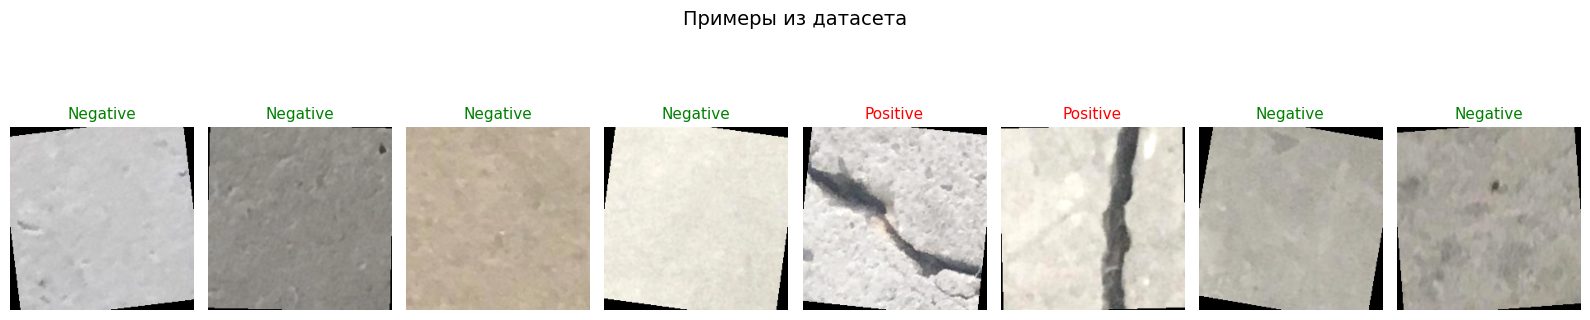

In [10]:
def show_samples(dataset, n=8):
    fig, axes = plt.subplots(1, n, figsize=(16, 4))
    inv_normalize = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )
    indices = np.random.choice(len(dataset), n, replace=False)
    for i, idx in enumerate(indices):
        img, label = dataset[idx]
        img = inv_normalize(img)
        img = img.permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)
        axes[i].imshow(img)
        class_name = full_dataset.classes[label]
        color = 'red' if class_name == 'Positive' else 'green'
        axes[i].set_title(class_name, color=color, fontsize=11)
        axes[i].axis('off')
    plt.suptitle("Примеры из датасета", fontsize=14)
    plt.tight_layout()
    plt.savefig("../notebooks/samples.png", dpi=150, bbox_inches='tight')
    plt.show()

show_samples(train_dataset)

In [11]:
# Загружаем ResNet18 с предобученными весами (Transfer Learning)
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Замораживаем все слои
for param in model.parameters():
    param.requires_grad = False

# Заменяем последний слой: 1000 классов ImageNet → 2 наших класса
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=LEARNING_RATE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Всего параметров: {total_params:,}")
print(f"Обучаемых: {trainable_params:,} ({trainable_params/total_params*100:.2f}%)")

Всего параметров: 11,177,538
Обучаемых: 1,026 (0.01%)


In [5]:
train_losses = []
train_accuracies = []

print("Начинаем обучение...\n")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        if (batch_idx + 1) % 100 == 0:
            print(f"  Эпоха [{epoch+1}/{EPOCHS}], "
                  f"Батч [{batch_idx+1}/{len(train_loader)}], "
                  f"Loss: {loss.item():.4f}")

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)
    print(f">>> Эпоха [{epoch+1}/{EPOCHS}] — "
          f"Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%\n")

print("Обучение завершено!")

Начинаем обучение...

  Эпоха [1/5], Батч [100/1000], Loss: 0.1087
  Эпоха [1/5], Батч [200/1000], Loss: 0.1584
  Эпоха [1/5], Батч [300/1000], Loss: 0.2293
  Эпоха [1/5], Батч [400/1000], Loss: 0.0825
  Эпоха [1/5], Батч [500/1000], Loss: 0.1047
  Эпоха [1/5], Батч [600/1000], Loss: 0.1339
  Эпоха [1/5], Батч [700/1000], Loss: 0.1059
  Эпоха [1/5], Батч [800/1000], Loss: 0.0952
  Эпоха [1/5], Батч [900/1000], Loss: 0.0640
  Эпоха [1/5], Батч [1000/1000], Loss: 0.0828
>>> Эпоха [1/5] — Loss: 0.1112, Accuracy: 96.53%

  Эпоха [2/5], Батч [100/1000], Loss: 0.0086
  Эпоха [2/5], Батч [200/1000], Loss: 0.0881
  Эпоха [2/5], Батч [300/1000], Loss: 0.0109
  Эпоха [2/5], Батч [400/1000], Loss: 0.0256
  Эпоха [2/5], Батч [500/1000], Loss: 0.0441
  Эпоха [2/5], Батч [600/1000], Loss: 0.0642
  Эпоха [2/5], Батч [700/1000], Loss: 0.0597
  Эпоха [2/5], Батч [800/1000], Loss: 0.0249
  Эпоха [2/5], Батч [900/1000], Loss: 0.0185
  Эпоха [2/5], Батч [1000/1000], Loss: 0.0974
>>> Эпоха [2/5] — Loss: 0.

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

model.eval()
correct = 0
total = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = 100 * correct / total
print(f"Точность на тестовой выборке: {test_accuracy:.2f}%\n")

# Матрица ошибок
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False
            xticklabels=['Negative\n(нет дефекта)', 'Positive\n(дефект)'],
            yticklabels=['Negative\n(нет дефекта)', 'Positive\n(дефект)'])
plt.xlabel('Предсказание модели')
plt.ylabel('Реальный класс')
plt.title(f'Матрица ошибок — Accuracy: {test_accuracy:.2f}%')
plt.tight_layout()
plt.savefig("../notebooks/confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

print("Подробный отчёт:")
print(classification_report(all_labels, all_preds,
                            target_names=['Negative', 'Positive']))

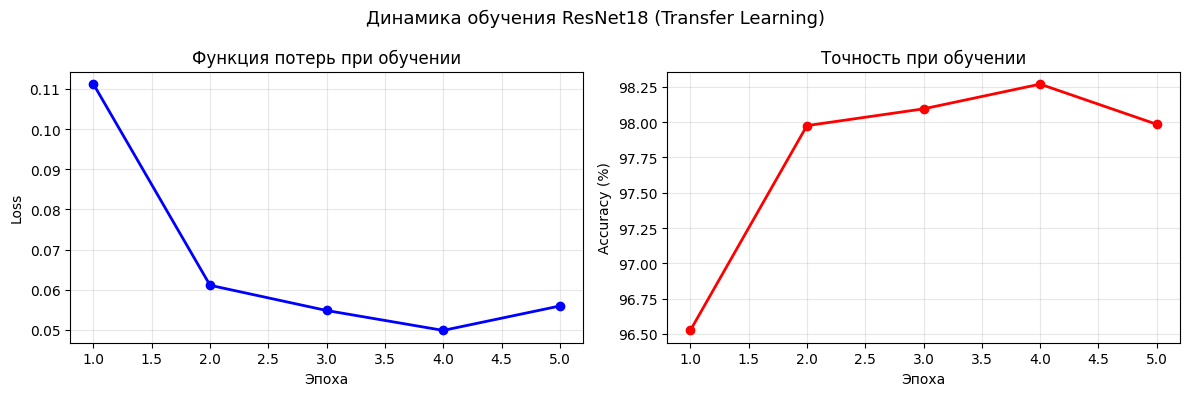

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, EPOCHS+1), train_losses, 'b-o', linewidth=2)
ax1.set_xlabel('Эпоха')
ax1.set_ylabel('Loss')
ax1.set_title('Функция потерь при обучении')
ax1.grid(True, alpha=0.3)

ax2.plot(range(1, EPOCHS+1), train_accuracies, 'r-o', linewidth=2)
ax2.set_xlabel('Эпоха')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Точность при обучении')
ax2.grid(True, alpha=0.3)

plt.suptitle('Динамика обучения ResNet18 (Transfer Learning)', fontsize=13)
plt.tight_layout()
plt.savefig("../notebooks/training_curves.png", dpi=150, bbox_inches='tight')
plt.show()

In [8]:
os.makedirs("../models", exist_ok=True)
MODEL_PATH = "../models/defect_model.pth"
torch.save(model.state_dict(), MODEL_PATH)

file_size = os.path.getsize(MODEL_PATH) / (1024 * 1024)
print(f"Модель сохранена: {MODEL_PATH}")
print(f"Размер файла: {file_size:.1f} МБ")

Модель сохранена: ../models/defect_model.pth
Размер файла: 42.7 МБ


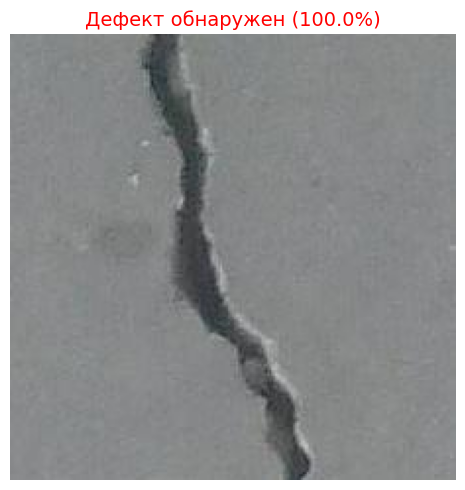

In [9]:
from PIL import Image

test_img_path = os.path.join(DATA_DIR, "Positive", os.listdir(os.path.join(DATA_DIR, "Positive"))[0])

img = Image.open(test_img_path).convert('RGB')
img_tensor = test_transform(img).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    output = model(img_tensor)
    probs = torch.softmax(output, dim=1)
    conf, pred = torch.max(probs, 1)

classes = ['Нет дефекта', 'Дефект обнаружен']
plt.figure(figsize=(5, 5))
plt.imshow(img)
color = 'red' if pred.item() == 1 else 'green'
plt.title(f"{classes[pred.item()]} ({conf.item()*100:.1f}%)", fontsize=14, color=color)
plt.axis('off')
plt.tight_layout()
plt.show()